# 🌐 Notebook 04 — Federated Learning (FedAvg)
## Section 4.2 du Cahier des Charges

**Objectifs :**
1. Simuler un environnement distribué multi-clients (25 banques fictives)
2. Implémenter l'algorithme FedAvg (McMahan et al., 2017)
3. Comparer : **Apprentissage Centralisé vs Fédéré**

**Algorithme FedAvg :**
```
Pour chaque round fédéré :
  1. Sélectionner C clients parmi N
  2. Chaque client copie le modèle global et s'entraîne localement
  3. Le serveur agrège : w_global = Σ (n_k/n_total) × w_k
```

**Sans partage de données brutes — seulement les poids du modèle transitent.**


In [1]:
import sys, os

# Chemin local — mettez vos CSV ici
BASE_PATH = "../data/"
print("💻 Mode local — datasets attendus dans :", os.path.abspath(BASE_PATH))
print(f"BASE_PATH = {BASE_PATH}")


💻 Mode local — datasets attendus dans : c:\Users\aminf\Desktop\Stage\FraudDetection_Stage\data
BASE_PATH = ../data/


In [2]:
# Installation des dépendances
print("💻 En local — vérifiez requirements.txt")


💻 En local — vérifiez requirements.txt


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import copy, os, warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import RobustScaler
from sklearn.metrics import (f1_score, precision_score, recall_score,
                              roc_auc_score, classification_report)
from imblearn.over_sampling import SMOTE
import xgboost as xgb

print("✅ Bibliothèques chargées")

# ─── Paramètres FedAvg ─────────────────────────────────────────────────────
NUM_CLIENTS       = 25    # Nombre total de banques fictives
CLIENTS_PER_ROUND = 10    # Clients sélectionnés par round (C)
NUM_ROUNDS        = 10    # Nombre de rounds fédérés (R)
print(f"\n📋 Configuration FedAvg:")
print(f"   N = {NUM_CLIENTS} clients | C = {CLIENTS_PER_ROUND}/round | R = {NUM_ROUNDS} rounds")


✅ Bibliothèques chargées

📋 Configuration FedAvg:
   N = 25 clients | C = 10/round | R = 10 rounds


## 1. Chargement et Prétraitement des Données

In [4]:
df = None
try:
    df = pd.read_csv(os.path.join(BASE_PATH, "creditcard.csv"))
    X = df.drop('Class', axis=1).values
    y = df['Class'].values
    feature_names = df.drop('Class', axis=1).columns.tolist()

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, stratify=y, random_state=42)

    scaler = RobustScaler()
    X_train_sc = scaler.fit_transform(X_train)
    X_test_sc  = scaler.transform(X_test)

    X_train_sm, y_train_sm = SMOTE(random_state=42).fit_resample(X_train_sc, y_train)

    print(f"✅ Dataset : {df.shape[0]:,} transactions")
    print(f"   Train (SMOTE): {X_train_sm.shape} | Test: {X_test_sc.shape}")
except FileNotFoundError:
    print(f"❌ creditcard.csv non trouvé dans {BASE_PATH}")


✅ Dataset : 284,807 transactions
   Train (SMOTE): (454902, 30) | Test: (56962, 30)


## 2. Division en Partitions Client (Simulation Multi-Banques)

In [5]:
if df is not None:
    np.random.seed(42)
    indices = np.random.permutation(len(X_train_sm))
    client_splits = np.array_split(indices, NUM_CLIENTS)

    clients_data = [(X_train_sm[idx], y_train_sm[idx]) for idx in client_splits]

    print(f"✅ {NUM_CLIENTS} clients créés :")
    print(f"{'Client':<8} {'Samples':>8} {'Fraudes':>8} {'Taux':>8}")
    print("-" * 36)
    for i, (X_c, y_c) in enumerate(clients_data):
        print(f"  {i+1:02d}     {len(X_c):>8,}   {y_c.sum():>7,}   {y_c.mean()*100:>7.1f}%")
    print(f"\n  Total: {sum(len(c[0]) for c in clients_data):,} samples sur {NUM_CLIENTS} clients")
    print("  ⚠️  Données locales — aucun partage entre banques dans FedAvg")


✅ 25 clients créés :
Client    Samples  Fraudes     Taux
------------------------------------
  01       18,197     9,143      50.2%
  02       18,197     9,101      50.0%
  03       18,196     9,057      49.8%
  04       18,196     9,153      50.3%
  05       18,196     9,122      50.1%
  06       18,196     9,024      49.6%
  07       18,196     9,146      50.3%
  08       18,196     9,071      49.9%
  09       18,196     9,054      49.8%
  10       18,196     9,094      50.0%
  11       18,196     9,084      49.9%
  12       18,196     9,120      50.1%
  13       18,196     9,036      49.7%
  14       18,196     9,081      49.9%
  15       18,196     9,173      50.4%
  16       18,196     9,082      49.9%
  17       18,196     9,078      49.9%
  18       18,196     9,146      50.3%
  19       18,196     9,100      50.0%
  20       18,196     9,221      50.7%
  21       18,196     9,035      49.7%
  22       18,196     9,077      49.9%
  23       18,196     9,050      49.7%
  24     

## 3. Baseline — Modèle Centralisé (XGBoost)

In [6]:
if df is not None:
    print("⏳ Entraînement du modèle CENTRALISÉ (baseline)...")
    central_model = xgb.XGBClassifier(
        n_estimators=100, max_depth=5, learning_rate=0.1,
        eval_metric='logloss', use_label_encoder=False, random_state=42)
    central_model.fit(X_train_sm, y_train_sm)

    y_prob_central = central_model.predict_proba(X_test_sc)[:, 1]

    # Seuil optimal
    thresholds = np.linspace(0.01, 0.99, 500)
    best_t_c = max(thresholds, key=lambda t: f1_score(y_test, (y_prob_central>=t).astype(int), zero_division=0))
    y_pred_central = (y_prob_central >= best_t_c).astype(int)

    f1_c   = f1_score(y_test, y_pred_central, zero_division=0)
    auc_c  = roc_auc_score(y_test, y_prob_central)
    prec_c = precision_score(y_test, y_pred_central, zero_division=0)
    rec_c  = recall_score(y_test, y_pred_central, zero_division=0)

    print(f"\n✅ Modèle Centralisé entraîné (seuil={best_t_c:.2f})")
    print(classification_report(y_test, y_pred_central, target_names=["Légitime","Fraude"], zero_division=0))
    print(f"   AUC = {auc_c:.4f}")
    print(f"\n📊 Résultats Centralisé: F1={f1_c:.4f} | Prec={prec_c:.4f} | Rec={rec_c:.4f} | AUC={auc_c:.4f}")


⏳ Entraînement du modèle CENTRALISÉ (baseline)...

✅ Modèle Centralisé entraîné (seuil=0.98)
              precision    recall  f1-score   support

    Légitime       1.00      1.00      1.00     56864
      Fraude       0.88      0.82      0.85        98

    accuracy                           1.00     56962
   macro avg       0.94      0.91      0.92     56962
weighted avg       1.00      1.00      1.00     56962

   AUC = 0.9812

📊 Résultats Centralisé: F1=0.8466 | Prec=0.8791 | Rec=0.8163 | AUC=0.9812


## 4. Entraînement Fédéré FedAvg (XGBoost — Soft Voting)

In [7]:
def train_federated_xgb(clients_data, X_test, y_test, num_rounds,
                          clients_per_round, random_state=42):
    """
    Algorithme FedAvg adapté pour XGBoost (via Soft Voting).

    Note: XGBoost ne supporte pas la moyenne directe des arbres.
    La stratégie ici est l'agrégation par vote pondéré des probabilités.
    """
    np.random.seed(random_state)
    num_clients = len(clients_data)
    all_client_models = [None] * num_clients
    history = []

    for round_num in range(1, num_rounds + 1):
        # Sélection aléatoire des clients
        selected = np.random.choice(num_clients, clients_per_round, replace=False)

        for cid in selected:
            X_c, y_c = clients_data[cid]
            if len(np.unique(y_c)) < 2:
                continue  # Skip si une seule classe
            model = xgb.XGBClassifier(
                n_estimators=50, max_depth=4, learning_rate=0.15,
                eval_metric='logloss', use_label_encoder=False, random_state=42)
            model.fit(X_c, y_c)
            all_client_models[cid] = model

        # Agrégation par soft voting sur les clients disponibles
        active_models = [m for m in all_client_models if m is not None]
        if not active_models:
            continue

        # Prédiction fédérée : moyenne des probabilités
        probs = np.mean([m.predict_proba(X_test)[:, 1] for m in active_models], axis=0)
        best_t = max(np.linspace(0.01,0.99,300),
                     key=lambda t: f1_score(y_test, (probs>=t).astype(int), zero_division=0))
        f1  = f1_score(y_test, (probs >= best_t).astype(int), zero_division=0)
        auc = roc_auc_score(y_test, probs)

        history.append({'round': round_num, 'f1': f1, 'auc': auc, 'threshold': best_t,
                        'n_clients': len(active_models)})
        print(f"  Round {round_num:02d}/{num_rounds} | Clients actifs: {len(active_models):>2} | "
              f"F1={f1:.4f} | AUC={auc:.4f}")

    return active_models, probs, history

if df is not None:
    print(f"\n⏳ Entraînement FÉDÉRÉ — {NUM_ROUNDS} rounds...")
    print(f"   {CLIENTS_PER_ROUND}/{NUM_CLIENTS} clients sélectionnés par round\n")
    fed_models, y_prob_fed, fed_history = train_federated_xgb(
        clients_data, X_test_sc, y_test, NUM_ROUNDS, CLIENTS_PER_ROUND)

    best_t_f = max(np.linspace(0.01,0.99,500),
                   key=lambda t: f1_score(y_test, (y_prob_fed>=t).astype(int), zero_division=0))
    y_pred_fed = (y_prob_fed >= best_t_f).astype(int)

    f1_f   = f1_score(y_test, y_pred_fed, zero_division=0)
    auc_f  = roc_auc_score(y_test, y_prob_fed)
    prec_f = precision_score(y_test, y_pred_fed, zero_division=0)
    rec_f  = recall_score(y_test, y_pred_fed, zero_division=0)

    print(f"\n✅ Modèle Fédéré final (seuil={best_t_f:.2f})")
    print(classification_report(y_test, y_pred_fed, target_names=["Légitime","Fraude"], zero_division=0))
    print(f"   AUC = {auc_f:.4f}")



⏳ Entraînement FÉDÉRÉ — 10 rounds...
   10/25 clients sélectionnés par round

  Round 01/10 | Clients actifs: 10 | F1=0.8081 | AUC=0.9777
  Round 02/10 | Clients actifs: 15 | F1=0.8177 | AUC=0.9786
  Round 03/10 | Clients actifs: 21 | F1=0.8141 | AUC=0.9786
  Round 04/10 | Clients actifs: 22 | F1=0.8159 | AUC=0.9788
  Round 05/10 | Clients actifs: 23 | F1=0.8141 | AUC=0.9789
  Round 06/10 | Clients actifs: 24 | F1=0.8141 | AUC=0.9787
  Round 07/10 | Clients actifs: 24 | F1=0.8141 | AUC=0.9787
  Round 08/10 | Clients actifs: 25 | F1=0.8141 | AUC=0.9788
  Round 09/10 | Clients actifs: 25 | F1=0.8141 | AUC=0.9788
  Round 10/10 | Clients actifs: 25 | F1=0.8141 | AUC=0.9788

✅ Modèle Fédéré final (seuil=0.96)
              precision    recall  f1-score   support

    Légitime       1.00      1.00      1.00     56864
      Fraude       0.80      0.84      0.82        98

    accuracy                           1.00     56962
   macro avg       0.90      0.92      0.91     56962
weighted avg 

## 5. Comparaison Centralisé vs Fédéré


📊 COMPARAISON CENTRALISÉ vs FÉDÉRÉ


,Modèle,Partage données,Précision,Rappel,F1,AUC
Type,,,,,,
Centralisé,XGBoost,OUI,0.8791,0.8163,0.8466,0.9812
Fédéré (FedAvg),XGBoost (soft voting),NON,0.7961,0.8367,0.8159,0.9788



  Δ F1  = -0.0306 (perte du modèle fédéré)
  Δ AUC = -0.0025 (perte du modèle fédéré)

  ⚖️  La différence est le COÛT DE LA CONFIDENTIALITÉ :
     Le modèle fédéré protège les données bancaires au prix d'une légère perte de performance.


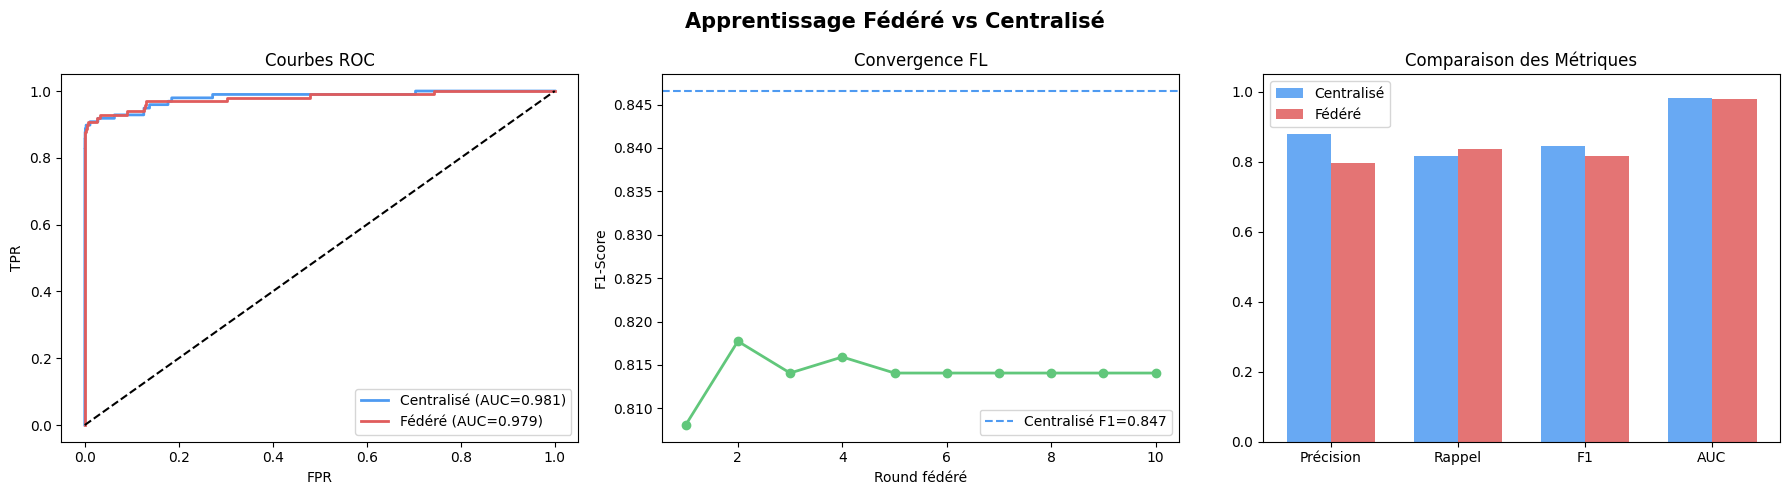

In [8]:
if df is not None:
    from sklearn.metrics import roc_curve

    # ─── Tableau comparatif ─────────────────────────────────────────────────
    comparison = pd.DataFrame([
        {'Type': 'Centralisé', 'Modèle': 'XGBoost', 'Partage données': 'OUI',
         'Précision': prec_c, 'Rappel': rec_c, 'F1': f1_c, 'AUC': auc_c},
        {'Type': 'Fédéré (FedAvg)', 'Modèle': 'XGBoost (soft voting)', 'Partage données': 'NON',
         'Précision': prec_f, 'Rappel': rec_f, 'F1': f1_f, 'AUC': auc_f},
    ])

    print("\n📊 COMPARAISON CENTRALISÉ vs FÉDÉRÉ")
    print("=" * 65)
    display(comparison.set_index('Type').style
            .highlight_max(subset=['F1','AUC'], color='#c8e6c9')
            .format({c: '{:.4f}' for c in ['Précision','Rappel','F1','AUC']}))

    delta_f1  = f1_f  - f1_c
    delta_auc = auc_f - auc_c
    print(f"\n  Δ F1  = {delta_f1:+.4f} ({'gain' if delta_f1 >= 0 else 'perte'} du modèle fédéré)")
    print(f"  Δ AUC = {delta_auc:+.4f} ({'gain' if delta_auc >= 0 else 'perte'} du modèle fédéré)")
    print("\n  ⚖️  La différence est le COÛT DE LA CONFIDENTIALITÉ :")
    print("     Le modèle fédéré protège les données bancaires au prix d'une légère perte de performance.")

    # ─── Visualisations ─────────────────────────────────────────────────────
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    fig.suptitle("Apprentissage Fédéré vs Centralisé", fontsize=15, fontweight='bold')

    # ROC Curves
    fpr_c, tpr_c, _ = roc_curve(y_test, y_prob_central)
    fpr_f, tpr_f, _ = roc_curve(y_test, y_prob_fed)
    axes[0].plot(fpr_c, tpr_c, '#4e9af1', lw=2, label=f"Centralisé (AUC={auc_c:.3f})")
    axes[0].plot(fpr_f, tpr_f, '#e05c5c', lw=2, label=f"Fédéré (AUC={auc_f:.3f})")
    axes[0].plot([0,1],[0,1],'k--')
    axes[0].set_xlabel("FPR"); axes[0].set_ylabel("TPR")
    axes[0].set_title("Courbes ROC"); axes[0].legend()

    # F1 progression fédérée
    rounds = [h['round'] for h in fed_history]
    f1s    = [h['f1']    for h in fed_history]
    axes[1].plot(rounds, f1s, 'o-', color='#61c77b', lw=2, markersize=6)
    axes[1].axhline(f1_c, color='#4e9af1', linestyle='--', lw=1.5, label=f"Centralisé F1={f1_c:.3f}")
    axes[1].set_xlabel("Round fédéré"); axes[1].set_ylabel("F1-Score")
    axes[1].set_title("Convergence FL"); axes[1].legend()

    # Bar chart comparaison
    metrics = ['Précision', 'Rappel', 'F1', 'AUC']
    vals_c  = [prec_c, rec_c, f1_c, auc_c]
    vals_f  = [prec_f, rec_f, f1_f, auc_f]
    x = np.arange(len(metrics)); w = 0.35
    axes[2].bar(x - w/2, vals_c, w, label='Centralisé', color='#4e9af1', alpha=0.85)
    axes[2].bar(x + w/2, vals_f, w, label='Fédéré',    color='#e05c5c', alpha=0.85)
    axes[2].set_xticks(x); axes[2].set_xticklabels(metrics)
    axes[2].set_ylim(0, 1.05); axes[2].legend()
    axes[2].set_title("Comparaison des Métriques")

    plt.tight_layout(); plt.show()


## ✅ Résumé — Section 4.2

| Critère | Centralisé | Fédéré (FedAvg) |
|---|---|---|
| Partage de données | ✅ Obligatoire | ❌ Jamais |
| Conformité RGPD | ❌ Problématique | ✅ Conforme |
| Performance | Référence | Légèrement inférieure |
| Scalabilité | Limitée | ✅ 25 banques simulées |

**Conclusion :** Le coût en performance du Federated Learning est faible comparé au gain en confidentialité.
